In [36]:
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import time

from numpy import ndarray

from kohonen import train
from kohonen_refactored import train as train_refactored, Config

In [47]:
np.random.seed(42)
input_data = np.random.random((10, 3))
n_max_iterations = 1000
width = np.arange(5, 50, 5)
height = np.arange(5, 50, 5)

## Benchmarking Baseline `train()`

In [48]:
def benchmark(
    data: ndarray, max_iterations: int, width_l: list[int], height_l: list[int]
) -> list[float]:
    results = []
    for l in range(len(width_l)):
        start = time.perf_counter()
        train(data, max_iterations, width_l[l], height_l[l])
        elapsed = time.perf_counter() - start

        results.append(elapsed)

    return results

In [49]:
b_results = benchmark(input_data, n_max_iterations, width, height)

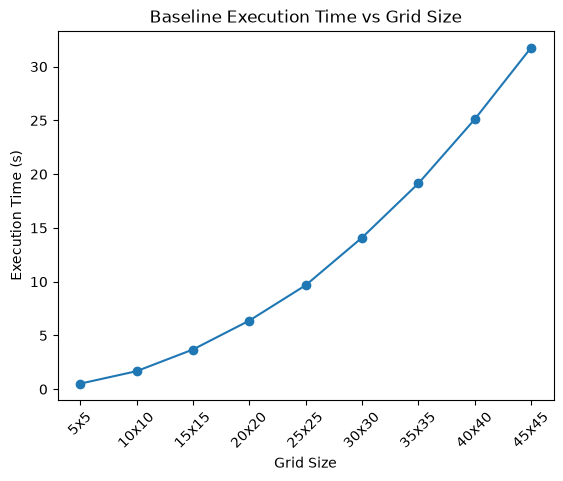

In [62]:
plt.plot(width, b_results, marker="o")

labels = [f"{w}x{w}" for w in width]
plt.xticks(width, labels, rotation=45)

plt.xlabel("Grid Size")
plt.ylabel("Execution Time (s)")
plt.title("Baseline Execution Time vs Grid Size")
plt.savefig("plots/baseline.png", dpi=300)

plt.show()

## Benchmarking the Refactored `train()`

In [51]:
def benchmark_refactored(
    data: ndarray, max_iterations: int, width_l: list[int], height_l: list[int]
) -> list[float]:
    results = []
    for l in range(len(width_l)):
        train_config = Config(
            n_max_iterations=max_iterations, width=width_l[l], height=height_l[l]
        )
        weights = np.random.random((width_l[l], height_l[l], 3))
        start = time.perf_counter()
        train_refactored(data, weights, train_config)
        elapsed = time.perf_counter() - start

        results.append(elapsed)

    return results

In [57]:
b_results_refactored = benchmark_refactored(input_data, n_max_iterations, width, height)

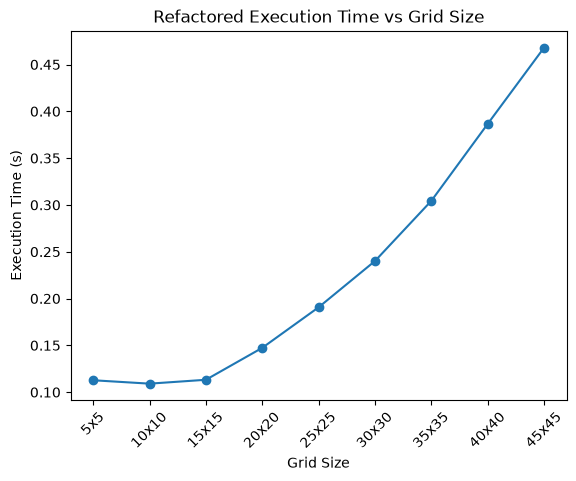

In [58]:
plt.plot(width, b_results_refactored, marker="o")

labels = [f"{w}x{w}" for w in width]
plt.xticks(width, labels, rotation=45)

plt.xlabel("Grid Size")
plt.ylabel("Execution Time (s)")
plt.title("Refactored Execution Time vs Grid Size")
plt.savefig("plots/refactored_execution_time.png", dpi=300)

plt.show()

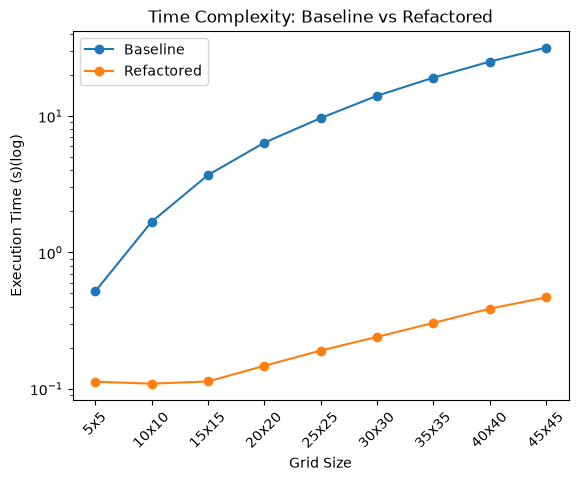

In [59]:
plt.plot(width, b_results, marker="o", label="Baseline")
plt.plot(width, b_results_refactored, marker="o", label="Refactored")

labels = [f"{w}x{w}" for w in width]
plt.xticks(width, labels, rotation=45)

plt.yscale("log")
plt.xlabel("Grid Size")
plt.ylabel("Execution Time (s)(log)")
plt.title("Time Complexity: Baseline vs Refactored")
plt.legend()
plt.savefig("plots/comparison.png", dpi=300)
plt.show()

## Log-log Fit Curves

In [60]:
log_w = np.log(width)
log_baseline = np.log(b_results)
log_refactored = np.log(b_results_refactored)

# slope, intercept
k_baseline, a_baseline = np.polyfit(log_w, log_baseline, 1)
k_refactored, a_refactored = np.polyfit(log_w, log_refactored, 1)

print(f"Baseline empirical order: n^{k_baseline:.2f}")
print(f"Refactored empirical order: n^{k_refactored:.2f}")

Baseline empirical order: n^1.89
Refactored empirical order: n^0.68
